In [154]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [155]:
df= pd.read_csv('../titanic_data_updated.csv')
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [156]:

df1= df.copy()
df1.head(4)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S


In [157]:
df1.drop(['PassengerId' , 'Name' , 'Ticket'] , axis=1 , inplace=True) #axis =1  culumn 
df1.head(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S


In [158]:
y= df1['Survived']  # target culumn
X = df1[['Pclass' , 'Sex' , 'Age' , 'SibSp' , 'Parch' , 'Fare' , 'Embarked']] # feature culumns

display(y.head(4))
display(X.head(4))

0     no
1    yes
2    yes
3    yes
Name: Survived, dtype: object

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S


Prediction on Survival ,

here survival target culumn  depends on Pclass,Sex ,Age ,SibSp ,Parch ,Farw , Embarked 

so target culumn is survival and feature culumns are Pclass ,Sex ,Age ,SibSp ,Parch ,Fare ,Embarked

target data -> y train
feature data -> X data 


to train the model  , we will train with 80% data  and test it with 20% data

Train data Split code 

In [159]:
from sklearn.model_selection import train_test_split #pip install scikit-learn
from sklearn.impute import SimpleImputer

X_train , X_test , y_train ,y_test = train_test_split(X,y , test_size=0.2 , random_state = 42)

display(X_train)  #80% of feature data
display(X_test)  #20% of feature data
display(y_train) #80% of target data
display(y_test) #20% of target data

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,S
270,first,male,NaN,0,0,31.0000,S
860,third,male,41.0,2,0,14.1083,S
435,first,female,14.0,1,2,120.0000,S


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,NaN,1,1,15.2458,C
439,second,male,31.0,0,0,10.5000,S
840,third,male,20.0,0,0,7.9250,S
720,second,female,6.0,0,1,33.0000,S
39,third,female,14.0,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,S
773,third,male,NaN,0,0,7.2250,C
25,third,female,38.0,1,5,31.3875,S
84,second,female,17.0,0,0,10.5000,S


331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

Numerical Missing Value Imputation with Pandas

In [160]:
display(X_train.isnull().sum())
display(X_test.isnull().sum())

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

Pclass       0
Sex          0
Age         37
SibSp        0
Parch        0
Fare         0
Embarked     0
dtype: int64

Mean Impute

In [161]:
age_mean = X_train['Age'].mean()
X_train["age mean imputer"] = X_train['Age'].fillna(age_mean)
X_test["age mean imputer"] = X_test['Age'].fillna(age_mean)

display(X_train.head(4)) 
display(X_test.head(4))

X_train["age mean imputer"].isnull().sum() 

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer
331,first,male,45.5,0,0,28.5000,S,45.5
733,second,male,23.0,0,0,13.0000,S,23.0
382,third,male,32.0,0,0,7.9250,S,32.0
704,third,male,26.0,1,0,7.8542,S,26.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer
709,third,male,NaN,1,1,15.2458,C,29.498846
439,second,male,31.0,0,0,10.5000,S,31.000000
840,third,male,20.0,0,0,7.9250,S,20.000000
720,second,female,6.0,0,1,33.0000,S,6.000000


np.int64(0)

Median Imputer

In [162]:
age_median =X_train['Age'].median()

X_train['age median imputer'] = X_train['Age'].fillna(age_median)

X_test['age median imputer'] = X_test['Age'].fillna(age_median)

display(X_train.head(4)) 
display(X_test.head(4))

X_train["age mean imputer"].isnull().sum() 

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer,age median imputer
331,first,male,45.5,0,0,28.5000,S,45.5,45.5
733,second,male,23.0,0,0,13.0000,S,23.0,23.0
382,third,male,32.0,0,0,7.9250,S,32.0,32.0
704,third,male,26.0,1,0,7.8542,S,26.0,26.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer,age median imputer
709,third,male,NaN,1,1,15.2458,C,29.498846,28.0
439,second,male,31.0,0,0,10.5000,S,31.000000,31.0
840,third,male,20.0,0,0,7.9250,S,20.000000,20.0
720,second,female,6.0,0,1,33.0000,S,6.000000,6.0


np.int64(0)

<Axes: xlabel='age mean imputer', ylabel='Density'>

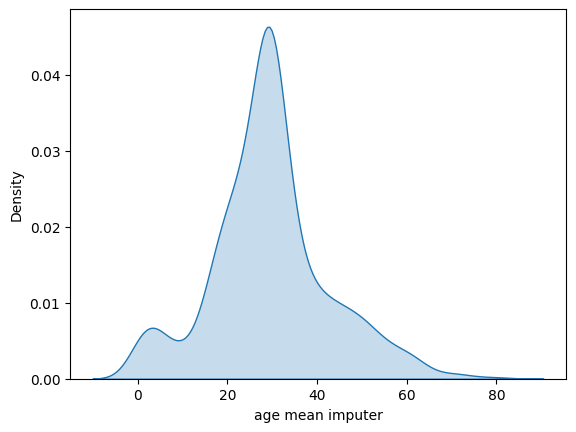

In [163]:
sns.kdeplot(data = X_train , x= X_train['age mean imputer'] , label = 'age mean imputer' , fill = True)


<Axes: xlabel='age median imputer', ylabel='Density'>

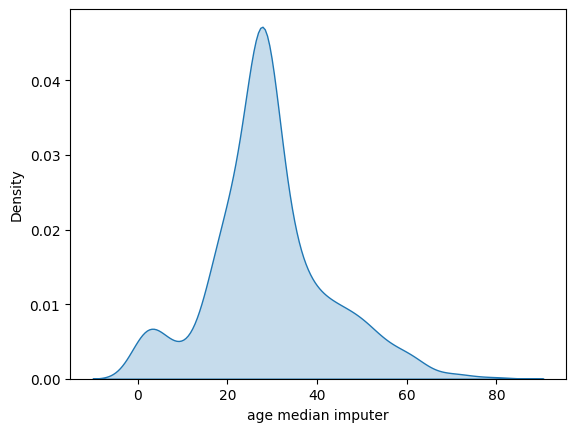

In [164]:
sns.kdeplot(data= X_train , x= X_train['age median imputer'] , label = 'age median imputer' , fill = True)

Numerical Missing Values Imputation using Simple Imputer

In [165]:
age_imputer =  SimpleImputer(missing_values=np.nan , strategy = 'mean')
# SImpleImputer(missing_values=np.nan , strategy = 'mean') -> SImpleImputer(key word arguments)


age_imputer.fit(X_train[["Age"]]) # [[age]] is 2D data, [age] is 1D data
#fit is a method call on the age_imputer object; it computes and stores parameters (the mean) from the passed data.
#returns 2D data

X_train['Age']= age_imputer.transform(X_train[['Age']]).ravel()  
#transform is a method call on the age_imputer object; it applies the imputation (filling in missing values) to the passed data.
#ravel makes 2D to 1D data

In [166]:
display(X_train.isnull().sum())

display(len(X_train))
#X_train.drop(['age mean imputer', 'age median imputer'], axis=1, inplace=True)

display(X_train.head(4))

Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              2
age mean imputer      0
age median imputer    0
dtype: int64

712

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer,age median imputer
331,first,male,45.5,0,0,28.5000,S,45.5,45.5
733,second,male,23.0,0,0,13.0000,S,23.0,23.0
382,third,male,32.0,0,0,7.9250,S,32.0,32.0
704,third,male,26.0,1,0,7.8542,S,26.0,26.0


In [167]:
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()
display(X_test.isnull().sum())
display(X_test.head(4))


Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              0
age mean imputer      0
age median imputer    0
dtype: int64

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,age mean imputer,age median imputer
709,third,male,29.498846,1,1,15.2458,C,29.498846,28.0
439,second,male,31.000000,0,0,10.5000,S,31.000000,31.0
840,third,male,20.000000,0,0,7.9250,S,20.000000,20.0
720,second,female,6.000000,0,1,33.0000,S,6.000000,6.0


#### Dropping age mean imputer and age median imputer columns from train and test data ####

In [168]:
X_test.drop(['age mean imputer','age median imputer'],axis=1,inplace=True)
X_train.drop(['age mean imputer','age median imputer'],axis=1,inplace=True)

X_train.head(4)
X_test.head(4)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,29.498846,1,1,15.2458,C
439,second,male,31.000000,0,0,10.5000,S
840,third,male,20.000000,0,0,7.9250,S
720,second,female,6.000000,0,1,33.0000,S


Categorical Value Imputation with Mode Value

In [169]:
embark_imputer = SimpleImputer(missing_values= np.nan , strategy = 'most_frequent')

embark_imputer.fit(X_train[['Embarked']]) 

X_train["Embarked"] = embark_imputer.transform(X_train[['Embarked']]).ravel()
X_test["Embarked"] = embark_imputer.transform(X_test[['Embarked']]).ravel()

In [170]:
X_train.isna().sum()
X_test.isna().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Categorical Value Imputation with Missing string and Indicator

Normal distribution        

# Outliners via Z score #

A z-score measures how many standard deviations a value is from the mean.

Formula: z = (x − μ) / σ

where x is the value, μ is the mean, and σ is the standard deviation. 

A z-score of 0 means exactly average; +2 means 2 SDs above; −1 means 1 SD below. 
 
 -1μ to +1μ covers 68% data 

-2μ to +2μ covers 95% data

-3μ to +3μ covers 99.7% data

beyond this is outliners  

z score works best on normal distribution data.

In [171]:
from IPython.display import Image, display
display(Image(filename='images.jpeg'))

FileNotFoundError: [Errno 2] No such file or directory: 'images.jpeg'

In [ ]:
X_train.describe()

,Age,SibSp,Parch,Fare
count,572.000000,712.000000,712.000000,712.000000
mean,29.498846,0.553371,0.379213,32.586276
std,14.500059,1.176404,0.791669,51.969529
min,0.420000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,0.000000,7.925000
50%,28.000000,0.000000,0.000000,14.454200
75%,38.000000,1.000000,0.000000,30.500000
max,80.000000,8.000000,6.000000,512.329200


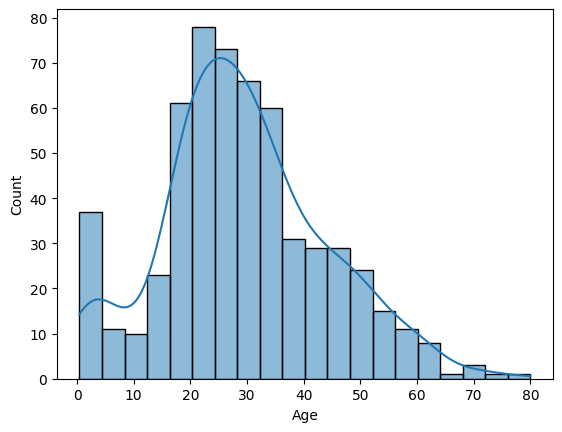

In [ ]:
sns.histplot(data=X_train['Age'] , kde=True)
plt.show()

In [172]:
mean= X_train['Age'].mean()
std = X_train['Age'].std()

X_train['Z_score'] = (X_train['Age']-mean) /std

outliners = X_train [abs(X_train['Z_score']) > 3]

print('Z_SCore Outliers in Age:', len(outliners)) 

print(outliners)


Z_SCore Outliers in Age: 5
     Pclass   Sex   Age  SibSp  Parch    Fare Embarked   Z_score
116   third  male  70.5      0      0   7.750        Q  3.155317
745   first  male  70.0      1      1  71.000        S  3.116839
630   first  male  80.0      0      0  30.000        S  3.886407
851   third  male  74.0      0      0   7.775        S  3.424666
672  second  male  70.0      0      0  10.500        S  3.116839


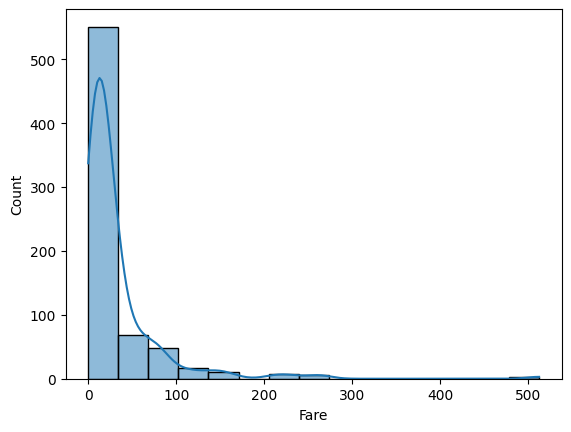

In [ ]:
sns.histplot(data=X_train['Fare'] , kde=True , bins=15)
plt.show()

In [176]:
mean_fare= X_train['Fare'].mean()
std_fare = X_train['Fare'].std()

X_train['Z_score_fare'] = (X_train['Fare']-mean_fare) /std_fare

outliners_fare = X_train [abs(X_train['Z_score_fare']) > 3]

print('Z_SCore Outliers in Fare:', len(outliners_fare)) 

print(outliners_fare)


Z_SCore Outliers in Fare: 17
    Pclass     Sex        Age  SibSp  Parch      Fare Embarked       Z_score  \
118  first    male  24.000000      0      1  247.5208        C -4.231736e-01   
716  first  female  38.000000      0      0  227.5250        C  6.542216e-01   
377  first    male  27.000000      0      2  211.5000        C -1.923032e-01   
742  first  female  21.000000      2      2  262.3750        C -6.540440e-01   
380  first  female  42.000000      0      0  227.5250        C  9.620488e-01   
779  first  female  43.000000      0      1  211.3375        S  1.039006e+00   
730  first  female  29.000000      0      0  211.3375        S -3.838960e-02   
88   first  female  23.000000      3      2  263.0000        S -5.001304e-01   
341  first  female  24.000000      3      2  263.0000        S -4.231736e-01   
557  first    male  29.498846      0      0  227.5250        C  2.734055e-16   
737  first    male  35.000000      0      0  512.3292        C  4.233512e-01   
679  first 

Outlines via IQR

The IQR tells you the range of the middle 50% of your data. It ignores extreme values (outliers), so it’s a robust measure of spread.

IQR=Q3-Q1


Q1 (First Quartile): 25% of data falls below this value
Q3 (Third Quartile): 75% of data falls below this value

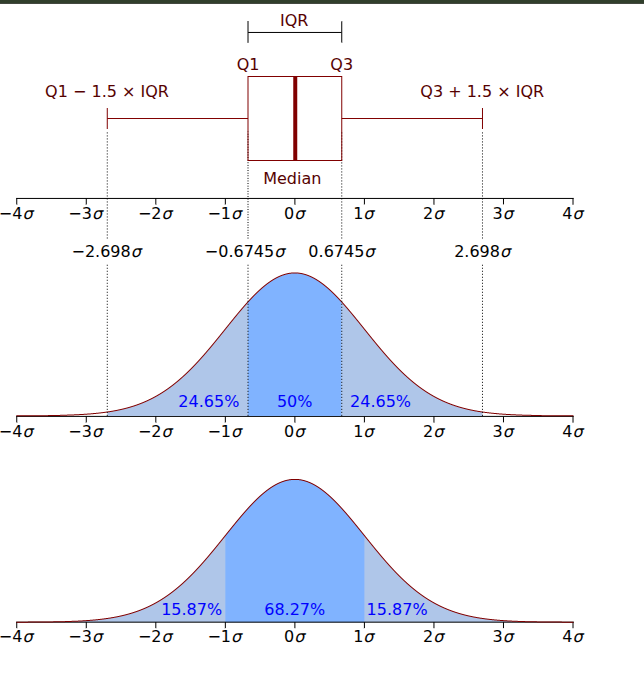

In [175]:
from IPython.display import Image, display
display(Image(filename='IQR_Z_SCore.png'))

## IQR OUTLINER ##

In [177]:
age_Q1=X_train['Age'].quantile(0.25)

age_Q3=X_train['Age'].quantile(0.75)

age_IQR= age_Q3 - age_Q1

age_minimum = age_Q1-1.5*age_IQR

age_maximum = age_Q3 + 1.5*age_IQR

print(age_minimum)
print(age_maximum)



2.5
54.5


In [178]:
age_outliners= X_train[(X_train['Age']< age_minimum) | (X_train['Age'] > age_maximum)]

print("IQR Outliers in Age:", len(age_outliners))

IQR Outliers in Age: 54


In [179]:

fare_Q1=X_train['Fare'].quantile(0.25)

fare_Q3=X_train['Fare'].quantile(0.75)

fare_IQR= fare_Q3 - fare_Q1

fare_minimum = max(0, fare_Q1-1.5*fare_IQR)

fare_maximum = fare_Q3 + 1.5*fare_IQR

print(fare_minimum)
print(fare_maximum)



0
64.3625


In [180]:
Fare_outliners= X_train[(X_train['Fare']< fare_minimum) | (X_train['Fare'] > fare_maximum)]


print("IQR Outliers in Fare:", len(Fare_outliners))

IQR Outliers in Fare: 96


## Z_Score vs IQR ##

## Z_Score is **mean** based and sensitive to outliers, while IQR is robust and not affected by outliers. ##

### ZScore is suitable for normally distributed data, ###

### while IQR can be used for any distribution (skewed or not).  

### here Z_SCore age outlines are 5 and IQR age outlines are 54  ###
### and Z_SCore fare outlines are 17 and IQR fare outlines are 96  ###
### age is normal distribution data and fare is skewed distribution data ####
### so for age Z_Score method is better and for fare IQR method is better ###

In [181]:
#for age outlines Z_score method is better ( normally distributed data)

print('total train samples:', len(X_train))
outliners = X_train [abs(X_train['Z_score']) > 3]
X_train= X_train [abs(X_train['Z_score']) <= 3]

print('number of outliers:', len(outliners))
print('number of final samples without outliers:', len(X_train))
display(X_train.head(4))


total train samples: 712
number of outliers: 5
number of final samples without outliers: 707


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Z_score,Z_score_fare
331,first,male,45.5,0,0,28.5000,S,1.231398,-0.078628
733,second,male,23.0,0,0,13.0000,S,-0.500130,-0.376880
382,third,male,32.0,0,0,7.9250,S,0.192481,-0.474533
704,third,male,26.0,1,0,7.8542,S,-0.269260,-0.475896


Clipping fare values (0-64.5)

In [182]:
# fare outliners IQR method is better ( skewed distribution data)
print('total train samples:', len(X_train))

#X_train_final= X_train[(X_train['Fare']>= fare_minimum) & (X_train['Fare'] <= fare_maximum)]


print("IQR Outliers in Fare:", len(Fare_outliners))
# instead of droping the 96 outlines , we would clip them 

X_train['Fare'] = X_train['Fare'].clip(lower=fare_minimum, upper=fare_maximum)
X_train['Fare'].describe()


total train samples: 707
IQR Outliers in Fare: 96


count    707.000000
mean      23.726125
std       20.155870
min        0.000000
25%        7.925000
50%       14.454200
75%       30.500000
max       64.362500
Name: Fare, dtype: float64

#### Dropping the Z score culumns  ####

In [184]:
X_train.head(4)
X_train.drop(['Z_score','Z_score_fare'],axis=1,inplace=True)
X_train.head(4)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S


#### Saving X_train.csv so far ####

In [185]:
X_train.to_csv('X_train.csv', index=False)
print('Saved X_train.csv')

Saved X_train.csv


## ENCODING ##

#### Encoding is the process of converting categorical data into numerical format s ####

#### Ordinal based on order and in nominal category order is not considered  (one hot encoding ) ####

In [188]:

from sklearn.preprocessing import OrdinalEncoder

pclass_encoder = OrdinalEncoder(categories = [['third' , 'second' , 'first']]) #  third < second < first

pclass_encoder.fit(X_train[['Pclass']]) # passing data to the encoder to learn the mapping of categories to numbers

X_train['encoded Pclass'] = pclass_encoder.transform(X_train[['Pclass']]).ravel() # applying the learned mapping to transform the data to numerical 
X_test['encoded Pclass'] = pclass_encoder.transform(X_test[['Pclass']]).ravel() # applying the learned mapping to transform the data to numerical 

display(X_train.head(4))
display(X_test.head(4))

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,encoded Pclass
331,first,male,45.5,0,0,28.5000,S,2.0
733,second,male,23.0,0,0,13.0000,S,1.0
382,third,male,32.0,0,0,7.9250,S,0.0
704,third,male,26.0,1,0,7.8542,S,0.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,encoded Pclass
709,third,male,29.498846,1,1,15.2458,C,0.0
439,second,male,31.000000,0,0,10.5000,S,1.0
840,third,male,20.000000,0,0,7.9250,S,0.0
720,second,female,6.000000,0,1,33.0000,S,1.0


#### Nominal Encoding (One hot ENcoding ) ####

In [190]:
from sklearn.preprocessing import OneHotEncoder

gender_encode = OneHotEncoder(sparse_output=False ).set_output(transform="pandas") # to get output in pandas dataframe format  insted of numpy 

# sparse_output=False -> to get output in dense array format 
# instead of sparse matrix format

gender_encode.fit(X_train[['Sex']])

gender_encoded_train=gender_encode.transform(X_train[['Sex']]) 
gender_encoded_test=gender_encode.transform(X_test[['Sex']])

X_train = pd.concat([X_train , gender_encoded_train] , axis =1 )
X_test = pd.concat([X_test , gender_encoded_test] , axis =1 )


display(X_train.head(4))
display(X_test.head(4))
 




,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,encoded Pclass,Sex_female,Sex_male
331,first,male,45.5,0,0,28.5000,S,2.0,0.0,1.0
733,second,male,23.0,0,0,13.0000,S,1.0,0.0,1.0
382,third,male,32.0,0,0,7.9250,S,0.0,0.0,1.0
704,third,male,26.0,1,0,7.8542,S,0.0,0.0,1.0


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,encoded Pclass,Sex_female,Sex_male
709,third,male,29.498846,1,1,15.2458,C,0.0,0.0,1.0
439,second,male,31.000000,0,0,10.5000,S,1.0,0.0,1.0
840,third,male,20.000000,0,0,7.9250,S,0.0,0.0,1.0
720,second,female,6.000000,0,1,33.0000,S,1.0,1.0,0.0


### Level Encoding ( encoding Y data) , for target column encoding   ####

In [191]:
y_train 


331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [195]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# fit / learnn 
le.fit(y_train)
# transform / apply

y_train_encoded = le.transform(y_train)  # returns numpy array [0,0,1,1,0,]
y_test_encoded = le.transform(y_test)

#display(y_train_encoded)

type(y_train_encoded)



numpy.ndarray

In [ ]:
y_train=pd.Series(y_train_encoded , index= y_train.index , name = y_train.name) # convert numpy array to pandas series/ column 
y_test=pd.Series(y_test_encoded , index= y_test.index , name = y_test.name) 

display(y_train)
display(y_test)


331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64